# <span style="color:#0f766e; font-weight:700;">Analiza Danych (Python) - Lekcja 4</span>

1. [Mini-projekt: opóźnienia lotów](#1.-Mini-projekt:-opóźnienia-lotów)
2. [Najważniejsze operacje w praktyce](#2.-Najważniejsze-operacje-w-praktyce)
3. [Dane i przygotowanie środowiska](#3.-Dane-i-przygotowanie-środowiska)
4. [Zadania obowiązkowe (1-15)](#4.-Zadania-obowiązkowe-(1-15))
5. [Zadania dodatkowe (16-24)](#5.-Zadania-dodatkowe-(16-24))
6. [Najczęstsze błędy](#Najczęstsze-błędy)


# <span style="color:#0f766e; font-weight:700;">1. Mini-projekt: opóźnienia lotów</span>

W tej lekcji pracujemy na publicznym zbiorze **nycflights13**. To duży, realistyczny zestaw danych, który dobrze domyka materiał z lekcji 1-3:
- lekcja 1: import i organizacja pracy,
- lekcja 2: statystyka opisowa i wizualizacje,
- lekcja 3: operacje na `DataFrame`, łączenie tabel i reshaping.

Tutaj dokładamy pełny pipeline analityczny:
- audyt jakości danych,
- czyszczenie braków i wartości spoza zakresu,
- bezpieczne merge wielu tabel,
- budowę cech z czasu i opóźnień,
- odpowiedzi na pytania badawcze,
- krótki raport końcowy.

## <span style="color:#0f766e; font-weight:700;">Pytania badawcze Q1-Q5</span>

- Q1: Którzy przewoźnicy mają najniższe typowe opóźnienia odlotu przy sensownej liczebności lotów?
- Q2: Które kierunki mają najwyższe średnie opóźnienia przylotu?
- Q3: Jak warunki pogodowe wiążą się z opóźnieniami odlotu?
- Q4: Jak zmienia się punktualność w czasie: miesiąc, dzień tygodnia i godzina?
- Q5: Ile rekordów odrzuciliśmy podczas czyszczenia i dlaczego?


# <span style="color:#0f766e; font-weight:700;">2. Najważniejsze operacje w praktyce</span>



Najważniejsze operacje tej lekcji:
- `query()`, `loc[]`, `iloc[]` do czytelnego wybierania rekordów,
- `assign()`, `rename()`, `sort_values()`, `set_index()` do budowy pipeline'u,
- `groupby()`, `agg()`, `value_counts()`, `nunique()` do podsumowań,
- `merge(..., validate=...)` do bezpiecznego łączenia,
- `melt()`, `pivot_table()`, `crosstab()` do zmiany kształtu danych,
- `pd.to_datetime()` i `.dt` do pracy z czasem,
- `matplotlib` i `seaborn` do szybkich wykresów roboczych.


## <span style="color:#0f766e; font-weight:700;">Przykład 1: Tabele referencyjne i szybka diagnostyka</span>

Na początek warto zobaczyć, jak wyglądają mniejsze tabele pomocnicze. Dzięki temu łatwiej później planować sensowne merge.


In [1]:
# Importujemy bibliotekę pandas do pracy z tabelami.
import pandas as pd

# Rozpoczynamy blok bezpiecznego importu danych.
try:
    # Importujemy z pakietu tylko te tabele, które będą potrzebne w tym fragmencie.
    from nycflights13 import airlines, airports, planes
# Obsługujemy sytuację, w której pakiet z danymi nie jest dostępny.
except ImportError as exc:
    # Zwracamy czytelny komunikat z instrukcją instalacji pakietu.
    raise ImportError("Zainstaluj pakiet: pip install nycflights13") from exc

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print("airlines:", airlines.shape)

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(airlines.head())
# Wstawiamy pustą linię, aby oddzielić kolejne fragmenty wyniku.
print()

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print("airports:", airports.shape)

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(airports[["faa", "name", "tz", "tzone"]].head())
# Wstawiamy pustą linię, aby oddzielić kolejne fragmenty wyniku.
print()

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print("planes:", planes.shape)
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(planes[["tailnum", "manufacturer", "model", "seats"]].head())


/home/niemir/AnalizaDanychPythonKurs/.venv/lib/python3.14/site-packages/nycflights13/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename as _rf


airlines: (16, 2)
  carrier                    name
0      9E       Endeavor Air Inc.
1      AA  American Airlines Inc.
2      AS    Alaska Airlines Inc.
3      B6         JetBlue Airways
4      DL    Delta Air Lines Inc.

airports: (1458, 8)
   faa                           name  tz             tzone
0  04G              Lansdowne Airport  -5  America/New_York
1  06A  Moton Field Municipal Airport  -6   America/Chicago
2  06C            Schaumburg Regional  -6   America/Chicago
3  06N                Randall Airport  -5  America/New_York
4  09J          Jekyll Island Airport  -5  America/New_York

planes: (3322, 9)
  tailnum      manufacturer      model  seats
0  N10156           EMBRAER  EMB-145XR     55
1  N102UW  AIRBUS INDUSTRIE   A320-214    182
2  N103US  AIRBUS INDUSTRIE   A320-214    182
3  N104UW  AIRBUS INDUSTRIE   A320-214    182
4  N10575           EMBRAER  EMB-145LR     55


## <span style="color:#0f766e; font-weight:700;">Przykład 2: Wybieranie kolumn, filtrowanie, `query`, `loc`, `iloc`</span>

Najpierw ćwiczymy czyste operacje na fragmentach danych.


In [ ]:
# Importujemy bibliotekę pandas do pracy z tabelami.
import pandas as pd

# Importujemy z pakietu tylko te tabele, które będą potrzebne w tym fragmencie.
from nycflights13 import flights

# Tworzymy tabelę `flights_day1` przez filtrowanie danych i zapisujemy wynik jako niezależną kopię.
flights_day1 = flights.query("month == 1 and day == 1").copy()

# Zapisujemy wynik bieżącej operacji do zmiennej `selected_day1`.
selected_day1 = flights_day1[["carrier", "origin", "dest", "distance", "air_time", "dep_delay"]]
# Wyświetlamy nagłówek lub komunikat: '"WYBRANE KOLUMNY:'.
print("WYBRANE KOLUMNY:")

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(selected_day1.head())
# Wstawiamy pustą linię, aby oddzielić kolejne fragmenty wyniku.
print()

# Zapisujemy wynik bieżącej operacji do zmiennej `long_haul_day1`.
long_haul_day1 = selected_day1.query("distance >= 1500 and air_time >= 200")
# Wyświetlamy nagłówek lub komunikat: '"LOTY DALEKIEGO ZASIĘGU:'.
print("LOTY DALEKIEGO ZASIĘGU:")
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(long_haul_day1.head())
# Wstawiamy pustą linię, aby oddzielić kolejne fragmenty wyniku.
print()

# Wyświetlamy nagłówek lub komunikat: '"LOC:'.
print("LOC:")
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(selected_day1.loc[selected_day1.index[:4], ["carrier", "dest", "distance"]])
# Wstawiamy pustą linię, aby oddzielić kolejne fragmenty wyniku.
print()

# Wyświetlamy nagłówek lub komunikat: '"ILOC:'.
print("ILOC:")
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(selected_day1.iloc[:4, :3])


## <span style="color:#0f766e; font-weight:700;">Przykład 3: Transformacje i nowe kolumny z `sched_dep_time`</span>

Tu ćwiczymy `assign()`, `rename()` i `sort_values()` na problemie pobocznym: jak czytać godziny zapisane jako liczby `HHMM`.


In [ ]:
# Importujemy bibliotekę pandas do pracy z tabelami.
import pandas as pd

# Tworzymy niezależną kopię danych i zapisujemy ją w zmiennej `schedule_demo`.
schedule_demo = flights.head(12).copy()
# Zmieniamy nazwy wybranych kolumn i zapisujemy wynik do `schedule_demo`.
schedule_demo = schedule_demo.rename(columns={"distance": "distance_miles"})
# Tworzymy lub nadpisujemy kolumnę `sched_dep_hour` w tabeli `schedule_demo`.
schedule_demo["sched_dep_hour"] = schedule_demo["sched_dep_time"] // 100
# Tworzymy lub nadpisujemy kolumnę `sched_dep_minute` w tabeli `schedule_demo`.
schedule_demo["sched_dep_minute"] = schedule_demo["sched_dep_time"] % 100
# Tworzymy lub nadpisujemy kolumnę `sched_arr_hour` w tabeli `schedule_demo`.
schedule_demo["sched_arr_hour"] = schedule_demo["sched_arr_time"] // 100
# Tworzymy lub nadpisujemy kolumnę `sched_arr_minute` w tabeli `schedule_demo`.
schedule_demo["sched_arr_minute"] = schedule_demo["sched_arr_time"] % 100
# Tworzymy lub nadpisujemy kolumnę `distance_km` w tabeli `schedule_demo`.
schedule_demo["distance_km"] = (schedule_demo["distance_miles"] * 1.609).round(1)
# Łączymy dwa kody lotnisk w jeden napis i zapisujemy go w kolumnie `route`.
schedule_demo["route"] = schedule_demo["origin"] + "-" + schedule_demo["dest"]
# Porządkujemy obiekt `schedule_demo` zgodnie z podaną regułą sortowania.
schedule_demo = schedule_demo.sort_values(["sched_dep_hour", "sched_dep_minute"])
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(schedule_demo[["route", "sched_dep_time", "sched_dep_hour", "sched_dep_minute", "distance_km"]])


## <span style="color:#0f766e; font-weight:700;">Przykład 4: `groupby`, `agg`, `nunique` na pytaniu pobocznym</span>

Zamiast analizować ogólne opóźnienia, policzymy ile czasu loty potrafiły „odrobić” w powietrzu.


In [ ]:
# Importujemy bibliotekę pandas do pracy z tabelami.
import pandas as pd

# Tworzymy tabelę `recovery_demo` po usunięciu rekordów z brakami w wybranych kolumnach.
recovery_demo = flights.dropna(subset=["dep_delay", "arr_delay", "carrier", "origin"]).copy()
# Obliczamy i zapisujemy w kolumnie `delay_recovery` różnicę między dwiema zmiennymi.
recovery_demo["delay_recovery"] = recovery_demo["dep_delay"] - recovery_demo["arr_delay"]
# Budujemy tabelę `recovery_summary` z agregacjami policzonymi dla każdej grupy.
recovery_summary = recovery_demo.groupby(["carrier", "origin"]).agg(
    # Zapisujemy wynik bieżącej operacji do zmiennej `flights_n`.
    flights_n=("flight", "count"),
    # Zapisujemy wynik bieżącej operacji do zmiennej `routes_n`.
    routes_n=("dest", "nunique"),
    # Zapisujemy wynik bieżącej operacji do zmiennej `recovery_mean`.
    recovery_mean=("delay_recovery", "mean"),
    # Zapisujemy wynik bieżącej operacji do zmiennej `recovery_median`.
    recovery_median=("delay_recovery", "median"),
# Domykamy bieżące wyrażenie lub blok parametrów.
)
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(recovery_summary.sort_values("recovery_mean", ascending=False).head(12).round(2))


## <span style="color:#0f766e; font-weight:700;">Przykład 5: `merge()` z tabelą `planes`</span>

Ćwiczymy merge na innym pytaniu niż w projekcie: jak wygląda rozkład liczby miejsc w samolotach używanych przez wybranych przewoźników.


In [ ]:
# Importujemy bibliotekę pandas do pracy z tabelami.
import pandas as pd

# Tworzymy tabelę `planes_demo` przez filtrowanie danych i zapisujemy wynik jako niezależną kopię.
planes_demo = flights.query("carrier in ['AA', 'DL', 'UA']").head(2000).copy()

# Tworzymy niezależną kopię danych i zapisujemy ją w zmiennej `planes_lookup`.
planes_lookup = planes[["tailnum", "manufacturer", "model", "seats", "engine"]].copy()

# Tworzymy obiekt `planes_demo` przez połączenie dwóch tabel na wspólnym kluczu.
planes_demo = planes_demo.merge(
    # Przekazujemy obiekt `planes_lookup` jako argument do bieżącej funkcji.
    planes_lookup,
    # Parametr `on` wskazuje kolumnę lub listę kolumn używanych jako klucz łączenia.
    on="tailnum",
    # Parametr `how` określa typ połączenia tabel i to, które rekordy zostają zachowane.
    how="left",
    # Parametr `validate` sprawdza, czy relacja między kluczami ma oczekiwaną strukturę.
    validate="many_to_one",
    # Parametr `indicator` dodaje kolumnę z informacją o źródle dopasowania po merge.
    indicator="merge_planes",
# Domykamy bieżące wyrażenie lub blok parametrów.
)

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(planes_demo["merge_planes"].value_counts())
# Wstawiamy pustą linię, aby oddzielić kolejne fragmenty wyniku.
print()

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(planes_demo[["carrier", "tailnum", "manufacturer", "model", "seats", "merge_planes"]].head(12))


## <span style="color:#0f766e; font-weight:700;">Przykład 6: `melt()` i `pivot_table()` na podsumowaniu miesięcznym</span>

To jest dobry moment, żeby przypomnieć zmianę kształtu danych z lekcji 3.


In [ ]:
# Importujemy bibliotekę pandas do pracy z tabelami.
import pandas as pd

# Budujemy tabelę `monthly_origin_demo` z agregacjami policzonymi dla każdej grupy.
monthly_origin_demo = flights.dropna(subset=["dep_delay", "arr_delay"]).groupby(["month", "origin"]).agg(
    # Zapisujemy wynik bieżącej operacji do zmiennej `dep_delay_mean`.
    dep_delay_mean=("dep_delay", "mean"),
    # Zapisujemy wynik bieżącej operacji do zmiennej `arr_delay_mean`.
    arr_delay_mean=("arr_delay", "mean"),
# Zamykamy agregację i zamieniamy indeks grupowania z powrotem na zwykłe kolumny.
).reset_index()

# Tworzymy tabelę przestawną i zapisujemy ją jako `monthly_origin_pivot`.
monthly_origin_pivot = monthly_origin_demo.pivot_table(
    # Parametr `index` wskazuje, co ma trafić do wierszy wyniku.
    index="month",
    # Parametr `columns` ustawia kolumny w wyniku albo słownik zmian nazw kolumn.
    columns="origin",
    # Parametr `values` wybiera zmienną, która ma być agregowana lub pokazana w tabeli.
    values="dep_delay_mean",
    # Parametr `aggfunc` określa funkcję agregującą używaną przy budowie tabeli.
    aggfunc="mean",
# Domykamy bieżące wyrażenie lub blok parametrów.
)

# Zapisujemy wynik bieżącej operacji do zmiennej `monthly_origin_long`.
monthly_origin_long = monthly_origin_pivot.reset_index().melt(
    # Parametr `id_vars` wskazuje kolumny, które mają pozostać identyfikatorami po stopieniu tabeli.
    id_vars="month",
    # Parametr `var_name` ustawia nazwę kolumny z dawnymi nagłówkami po operacji `melt`.
    var_name="origin",
    # Parametr `value_name` ustawia nazwę kolumny z wartościami po operacji `melt`.
    value_name="dep_delay_mean",
# Domykamy bieżące wyrażenie lub blok parametrów.
)

# Wyświetlamy nagłówek lub komunikat: '"PIVOT:'.
print("PIVOT:")
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(monthly_origin_pivot.head())
# Wstawiamy pustą linię, aby oddzielić kolejne fragmenty wyniku.
print()
# Wyświetlamy nagłówek lub komunikat: '"MELT:'.
print("MELT:")
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(monthly_origin_long.head(12))


## <span style="color:#0f766e; font-weight:700;">Przykład 7: `pd.to_datetime()`, `.dt` i `crosstab()`</span>

Na tym przykładzie ćwiczymy pracę z czasem oraz tabelę przekrojową.


In [ ]:
# Importujemy bibliotekę pandas do pracy z tabelami.
import pandas as pd

# Tworzymy niezależną kopię danych i zapisujemy ją w zmiennej `time_demo`.
time_demo = flights.head(5000).copy()
# Nadpisujemy kolumnę `time_hour` w tabeli `time_demo` po konwersji do typu datetime.
time_demo["time_hour"] = pd.to_datetime(time_demo["time_hour"], utc=True)
# Zapisujemy do kolumny `quarter` cechę czasu wyliczoną z daty.
time_demo["quarter"] = time_demo["time_hour"].dt.quarter
# Zapisujemy do kolumny `weekday` cechę czasu wyliczoną z daty.
time_demo["weekday"] = time_demo["time_hour"].dt.day_name()
# Tworzymy w kolumnie `is_weekend` flagę na podstawie sprawdzenia przynależności do listy.
time_demo["is_weekend"] = time_demo["weekday"].isin(["Saturday", "Sunday"])
# Tworzymy tabelę krzyżową i zapisujemy wynik do `weekend_table`.
weekend_table = pd.crosstab(
    # Przekazujemy jedną z kolumn wejściowych do tabeli krzyżowej.
    time_demo["quarter"],
    # Przekazujemy jedną z kolumn wejściowych do tabeli krzyżowej.
    time_demo["is_weekend"],
    # Parametr `normalize` zamienia liczebności na udziały według wskazanego kierunku normalizacji.
    normalize="index",
# Domykamy bieżące wyrażenie lub blok parametrów.
)
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(weekend_table)


## <span style="color:#0f766e; font-weight:700;">Przykład 8: Dwa wykresy robocze</span>




In [ ]:
# Importujemy moduł `pyplot` do budowy wykresów.
import matplotlib.pyplot as plt
# Importujemy bibliotekę seaborn do estetycznych wizualizacji.
import seaborn as sns

# Tworzymy tabelę `plot_demo` po usunięciu rekordów z brakami w wybranych kolumnach.
plot_demo = flights.dropna(subset=["distance", "air_time", "carrier", "origin"]).copy()

# Zapisujemy wynik bieżącej operacji do zmiennej `plot_demo`.
plot_demo = plot_demo.query("distance <= 3000 and air_time <= 450")

# Tworzymy nowe płótno wykresu z podanym rozmiarem.
plt.figure(figsize=(8, 4))

# Rysujemy wykres rozrzutu dla wskazanych zmiennych.
sns.scatterplot(
    # Parametr `data` wskazuje tabelę, z której funkcja ma pobrać dane.
    data=plot_demo.sample(min(2000, len(plot_demo)), random_state=42),
    # Parametr `x` wskazuje zmienną odkładaną na osi poziomej.
    x="distance",
    # Parametr `y` wskazuje zmienną odkładaną na osi pionowej.
    y="air_time",
    # Parametr `alpha` steruje przezroczystością elementów na wykresie.
    alpha=0.25,
# Domykamy bieżące wyrażenie lub blok parametrów.
)
# Ustawiamy tytuł wykresu.
plt.title("distance vs air_time")
# Ustawiamy podpis osi poziomej.
plt.xlabel("distance")
# Ustawiamy podpis osi pionowej.
plt.ylabel("air_time")
# Dopasowujemy marginesy, aby elementy wykresu się nie nakładały.
plt.tight_layout()
# Wyświetlamy gotowy wykres.
plt.show()

# Tworzymy nowe płótno wykresu z podanym rozmiarem.
plt.figure(figsize=(8, 4))

# Rysujemy wykres pudełkowy porównujący rozkład między kategoriami.
sns.boxplot(data=plot_demo[plot_demo["origin"].isin(["EWR", "JFK", "LGA"])], x="origin", y="air_time")
# Ustawiamy tytuł wykresu.
plt.title("air_time wg origin")
# Ustawiamy podpis osi poziomej.
plt.xlabel("origin")
# Ustawiamy podpis osi pionowej.
plt.ylabel("air_time")
# Dopasowujemy marginesy, aby elementy wykresu się nie nakładały.
plt.tight_layout()
# Wyświetlamy gotowy wykres.
plt.show()


# <span style="color:#0f766e; font-weight:700;">3. Dane i przygotowanie środowiska</span>

W tej lekcji pracujemy na pakiecie:
- `nycflights13`

Instalacja:
- `pip install nycflights13`

Główne tabele:
- `flights`
- `airlines`
- `airports`
- `weather`
- `planes`

Źródła:
- https://pypi.org/project/nycflights13/
- https://github.com/tidyverse/nycflights13


# <span style="color:#0f766e; font-weight:700;">4. Zadania obowiązkowe (1-15)</span>


## <span style="color:#0f766e; font-weight:700;">Zadanie 1</span>

Wczytaj wszystkie tabele z `nycflights13` i wykonaj pełną szybką diagnostykę.

Pracuj na tabelach:
- `flights`
- `airlines`
- `airports`
- `weather`
- `planes`

Dla każdej z nich pokaż:
- `shape`
- listę kolumn przez `columns`
- pierwsze 5 rekordów przez `head()`
- strukturę przez `info()`

Najlepiej zrób to w pętli po słowniku `{'flights': flights, ...}`.

Wymagane funkcje/parametry:
- `from nycflights13 import ...` - import tabel z pakietu.
- `shape`, `columns`, `head()`, `info()` - szybka diagnostyka.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pypi.org/project/nycflights13/
- https://pandas.pydata.org/docs/reference/frame.html


In [4]:
# tutaj dodaj swój kod
# - `flights`
# - `airlines`
# - `airports`
# - `weather`
# - `planes`
import pandas as pd
import numpy as np
try:
    # Importujemy z pakietu tylko te tabele, które będą potrzebne w tym fragmencie.
    from nycflights13 import airlines, airports, planes, flights, weather
# Obsługujemy sytuację, w której pakiet z danymi nie jest dostępny.
except ImportError as exc:
    # Zwracamy czytelny komunikat z instrukcją instalacji pakietu.
    raise ImportError("Zainstaluj pakiet: pip install nycflights13") from exc

tables = {'flights': flights, 'airlines': airlines, 'airports': airports, 'planes': planes, 'weather': weather }

for table_name, table in tables.items():
    print(table_name)
    print(table.shape)
    print(table.columns)
    print(table.info())
    display(table.head(5))

flights
(336776, 19)
Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'time_hour'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            336776 non-null  int64  
 1   month           336776 non-null  int64  
 2   day             336776 non-null  int64  
 3   dep_time        328521 non-null  float64
 4   sched_dep_time  336776 non-null  int64  
 5   dep_delay       328521 non-null  float64
 6   arr_time        328063 non-null  float64
 7   sched_arr_time  336776 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         336776 non-null  str    
 10  flight          336776 non-null  int64  
 11  tailnum      

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01T10:00:00Z
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01T11:00:00Z


airlines
(16, 2)
Index(['carrier', 'name'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   carrier  16 non-null     str  
 1   name     16 non-null     str  
dtypes: str(2)
memory usage: 388.0 bytes
None


,carrier,name
0,9E,Endeavor Air Inc.
1,AA,American Airlines Inc.
2,AS,Alaska Airlines Inc.
3,B6,JetBlue Airways
4,DL,Delta Air Lines Inc.


airports
(1458, 8)
Index(['faa', 'name', 'lat', 'lon', 'alt', 'tz', 'dst', 'tzone'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   faa     1458 non-null   str    
 1   name    1458 non-null   str    
 2   lat     1458 non-null   float64
 3   lon     1458 non-null   float64
 4   alt     1458 non-null   int64  
 5   tz      1458 non-null   int64  
 6   dst     1458 non-null   str    
 7   tzone   1455 non-null   str    
dtypes: float64(2), int64(2), str(4)
memory usage: 91.3 KB
None


,faa,name,lat,lon,alt,tz,dst,tzone
0,04G,Lansdowne Airport,41.130472,-80.619583,1044,-5,A,America/New_York
1,06A,Moton Field Municipal Airport,32.460572,-85.680028,264,-6,A,America/Chicago
2,06C,Schaumburg Regional,41.989341,-88.101243,801,-6,A,America/Chicago
3,06N,Randall Airport,41.431912,-74.391561,523,-5,A,America/New_York
4,09J,Jekyll Island Airport,31.074472,-81.427778,11,-5,A,America/New_York


planes
(3322, 9)
Index(['tailnum', 'year', 'type', 'manufacturer', 'model', 'engines', 'seats',
       'speed', 'engine'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 3322 entries, 0 to 3321
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   tailnum       3322 non-null   str    
 1   year          3252 non-null   float64
 2   type          3322 non-null   str    
 3   manufacturer  3322 non-null   str    
 4   model         3322 non-null   str    
 5   engines       3322 non-null   int64  
 6   seats         3322 non-null   int64  
 7   speed         23 non-null     float64
 8   engine        3322 non-null   str    
dtypes: float64(2), int64(2), str(5)
memory usage: 233.7 KB
None


,tailnum,year,type,manufacturer,model,engines,seats,speed,engine
0,N10156,2004.0,Fixed wing multi engine,EMBRAER,EMB-145XR,2,55,NaN,Turbo-fan
1,N102UW,1998.0,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NaN,Turbo-fan
2,N103US,1999.0,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NaN,Turbo-fan
3,N104UW,1999.0,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NaN,Turbo-fan
4,N10575,2002.0,Fixed wing multi engine,EMBRAER,EMB-145LR,2,55,NaN,Turbo-fan


weather
(26115, 15)
Index(['origin', 'year', 'month', 'day', 'hour', 'temp', 'dewp', 'humid',
       'wind_dir', 'wind_speed', 'wind_gust', 'precip', 'pressure', 'visib',
       'time_hour'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 26115 entries, 0 to 26114
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26115 non-null  str    
 1   year        26115 non-null  int64  
 2   month       26115 non-null  int64  
 3   day         26115 non-null  int64  
 4   hour        26115 non-null  int64  
 5   temp        26114 non-null  float64
 6   dewp        26114 non-null  float64
 7   humid       26114 non-null  float64
 8   wind_dir    25655 non-null  float64
 9   wind_speed  26111 non-null  float64
 10  wind_gust   5337 non-null   float64
 11  precip      26115 non-null  float64
 12  pressure    23386 non-null  float64
 13  visib       26115 non-null  float64
 14  time_hour   26115 non-null  st

,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,EWR,2013,1,1,1,39.02,26.06,59.37,270.0,10.35702,NaN,0.0,1012.0,10.0,2013-01-01T06:00:00Z
1,EWR,2013,1,1,2,39.02,26.96,61.63,250.0,8.05546,NaN,0.0,1012.3,10.0,2013-01-01T07:00:00Z
2,EWR,2013,1,1,3,39.02,28.04,64.43,240.0,11.50780,NaN,0.0,1012.5,10.0,2013-01-01T08:00:00Z
3,EWR,2013,1,1,4,39.92,28.04,62.21,250.0,12.65858,NaN,0.0,1012.2,10.0,2013-01-01T09:00:00Z
4,EWR,2013,1,1,5,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0,2013-01-01T10:00:00Z


## <span style="color:#0f766e; font-weight:700;">Zadanie 2</span>

Przygotuj audyt jakości dla `flights` i `weather`.

Dla obu tabel zbuduj osobną tabelę audytu z dwiema kolumnami:
- `missing_n`
- `missing_pct`

Następnie:
- w `flights` policz duplikaty pełnych rekordów,
- w `weather` policz duplikaty po kluczu `origin`, `year`, `month`, `day`, `hour`.

Na końcu pokaż:
- `head(12)` dla tabeli braków `flights`,
- `head(12)` dla tabeli braków `weather`,
- liczbę duplikatów w obu przypadkach.

Wymagane funkcje/parametry:
- `isna().sum()` i `isna().mean()` - podsumowanie braków.
- `duplicated()` - wykrywanie duplikatów.
- `sort_values()` - ranking kolumn z największym problemem.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html


In [5]:
# tutaj dodaj swój kod
flights_missing = pd.DataFrame({
    'missing_n': flights.isna().sum(),
    'missing_pct': flights.isna().mean(),
})
flights_duplicated = flights.duplicated().sum(),
weather_missing = pd.DataFrame({
    'missing_n': weather.isna().sum(),
    'missing_pct': weather.isna().mean(),
})
weahter_duplicated = weather.duplicated(subset=['origin', 'year', 'month', 'day', 'hour']).sum()
flights_missing = flights_missing.sort_values(['missing_n', 'missing_pct'], ascending=[False, False])
weather_missing = weather_missing.sort_values(['missing_n', 'missing_pct'], ascending=[False, False])
print(f"Flights duplicated: {flights_duplicated[0]}")
print(f"Weather duplicated: {weahter_duplicated}")
display(flights_missing.head(12))
display(weather_missing.head(12))

Flights duplicated: 0
Weather duplicated: 3


,missing_n,missing_pct
arr_delay,9430,0.028001
air_time,9430,0.028001
arr_time,8713,0.025872
dep_time,8255,0.024512
dep_delay,8255,0.024512
tailnum,2512,0.007459
year,0,0.000000
month,0,0.000000
day,0,0.000000
sched_dep_time,0,0.000000


,missing_n,missing_pct
wind_gust,20778,0.795635
pressure,2729,0.104499
wind_dir,460,0.017614
wind_speed,4,0.000153
temp,1,0.000038
dewp,1,0.000038
humid,1,0.000038
origin,0,0.000000
year,0,0.000000
month,0,0.000000


## <span style="color:#0f766e; font-weight:700;">Zadanie 3</span>

Przygotuj roboczą tabelę `project_flights` tylko z kolumnami potrzebnymi do projektu.

Wybierz z `flights` dokładnie te kolumny:
- `year`
- `month`
- `day`
- `dep_time`
- `sched_dep_time`
- `dep_delay`
- `arr_time`
- `sched_arr_time`
- `arr_delay`
- `carrier`
- `flight`
- `tailnum`
- `origin`
- `dest`
- `air_time`
- `distance`
- `hour`
- `minute`
- `time_hour`

Zapisz wynik pod nazwą `project_flights`.

To jest zestaw potrzebny później do:
- czyszczenia braków,
- walidacji zakresów,
- budowy nowych cech,
- łączenia z pogodą, przewoźnikami i lotniskami.

Następnie pokaż 10 rekordów o największym `distance` przez `query()` lub `sort_values()`.

Wymagane funkcje/parametry:
- wybór kolumn `df[[...]]` - budowa węższej tabeli roboczej.
- `query()` albo `sort_values()` - podgląd skrajnych rekordów.
- `copy()` - bezpieczna kopia danych.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html


In [6]:
# tutaj dodaj swój kod
project_flights = flights.copy()[['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay', 'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight', 'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute', 'time_hour']]
project_flights.to_csv('./dane_lekcja4/project_flights.csv', index=False)
display(project_flights.sort_values(['distance'], ascending=False))

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
118311,2013,2,9,1206.0,900,186.0,1814.0,1540,154.0,HA,51,N380HA,JFK,HNL,645.0,4983,9,0,2013-02-09T14:00:00Z
227103,2013,6,6,1044.0,1000,44.0,1441.0,1435,6.0,HA,51,N384HA,JFK,HNL,580.0,4983,10,0,2013-06-06T14:00:00Z
224146,2013,6,3,957.0,1000,-3.0,1432.0,1435,-3.0,HA,51,N381HA,JFK,HNL,605.0,4983,10,0,2013-06-03T14:00:00Z
170226,2013,4,6,957.0,1000,-3.0,1510.0,1510,0.0,HA,51,N382HA,JFK,HNL,638.0,4983,10,0,2013-04-06T14:00:00Z
130088,2013,2,22,857.0,900,-3.0,1436.0,1540,-64.0,HA,51,N382HA,JFK,HNL,606.0,4983,9,0,2013-02-22T14:00:00Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115505,2013,2,5,2136.0,2130,6.0,2238.0,2225,13.0,EV,4619,N26141,EWR,PHL,31.0,80,21,30,2013-02-06T02:00:00Z
25145,2013,1,29,2131.0,2130,1.0,2221.0,2225,-4.0,EV,4619,N13538,EWR,PHL,25.0,80,21,30,2013-01-30T02:00:00Z
170692,2013,4,6,1948.0,1950,-2.0,2034.0,2044,-10.0,EV,4457,N29917,EWR,PHL,25.0,80,19,50,2013-04-06T23:00:00Z
112694,2013,2,2,1610.0,1617,-7.0,1702.0,1722,-20.0,EV,4616,N18120,EWR,PHL,33.0,80,16,17,2013-02-02T21:00:00Z


## <span style="color:#0f766e; font-weight:700;">Zadanie 4</span>

Zbuduj `flights_no_missing` przez usunięcie braków w kluczowych kolumnach.

Pracuj na `project_flights` z zadania 3.

Usuń rekordy z brakami w dokładnie tych kolumnach:
- `dep_delay`
- `arr_delay`
- `carrier`
- `dest`
- `time_hour`
- `air_time`
- `distance`

Zapisz wynik pod nazwą `flights_no_missing`.

Pokaż:
- rozmiar `project_flights`,
- rozmiar `flights_no_missing`,
- liczbę usuniętych rekordów.

Wymagane funkcje/parametry:
- `dropna(subset=[...])` - usuwanie braków w wybranych kolumnach.
- `shape` - porównanie rozmiaru tabeli przed i po czyszczeniu.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html


In [7]:
# tutaj dodaj swój kod
# - `dep_delay`
# - `arr_delay`
# - `carrier`
# - `dest`
# - `time_hour`
# - `air_time`
# - `distance`
flights_no_missing = project_flights.copy().dropna(subset=['dep_delay', 'arr_delay', 'carrier', 'dest', 'time_hour', 'air_time', 'distance'])
flights_no_missing.to_csv('./dane_lekcja4/flights_no_missing.csv', index=False)
print(f'project_flights shape: {project_flights.shape}')
print(f'flights_no_missing shape: {flights_no_missing.shape}')
print(f'difference: {project_flights.shape[0] - flights_no_missing.shape[0]}')

project_flights shape: (336776, 19)
flights_no_missing shape: (327346, 19)
difference: 9430


## <span style="color:#0f766e; font-weight:700;">Zadanie 5</span>

Zastosuj reguły jakości zakresów i utwórz `flights_clean`.

Pracuj na `flights_no_missing` z zadania 4.

Na potrzeby tej lekcji przyjmij dokładnie następujące zakresy:
- `dep_delay` od `-60` do `360`
- `arr_delay` od `-100` do `360`
- `air_time` od `20` do `500`
- `distance` od `80` do `5000`

Traktujemy je jako robocze reguły jakości na zajęciach:
- bardzo wczesne odloty poniżej `-60` minut odrzucamy,
- skrajnie duże opóźnienia powyżej `360` minut odrzucamy,
- loty z `air_time < 20` uznajemy za problematyczne,
- dystanse poza zakresem `80-5000` traktujemy jako niespójne dla tej analizy.

Zapisz wynik pod nazwą `flights_clean`.

Pokaż:
- rozmiar `flights_no_missing`,
- rozmiar `flights_clean`,
- liczbę rekordów odrzuconych przez walidację zakresów.

Wymagane funkcje/parametry:
- `between()` - kontrola zakresów liczbowych.
- maski logiczne `&` - łączenie reguł.
- `df[mask]` - filtrowanie poprawnych rekordów.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.Series.between.html


In [8]:
# tutaj dodaj swój kod
flights_clean = flights_no_missing.copy()
flights_clean = flights_clean[
    (flights_clean['dep_delay'].between(-60,360)) &
    (flights_clean['arr_delay'].between(-100,360)) &
    (flights_clean['air_time'].between(20,500)) &
    (flights_clean['distance'].between(80,5000))
]
print(flights_clean.shape)
print(f'filtered: {flights_no_missing.shape[0] - flights_clean.shape[0]}')
flights_clean.to_csv('./dane_lekcja4/flights_clean.csv', index=False)

(326369, 19)
filtered: 977


## <span style="color:#0f766e; font-weight:700;">Zadanie 6</span>

Przygotuj `weather_clean` do późniejszego merge z lotami.

Pracuj na tabeli `weather`.

Wybierz dokładnie te kolumny:
- `origin`
- `year`
- `month`
- `day`
- `hour`
- `temp`
- `wind_speed`
- `precip`
- `visib`
- `pressure`
- `time_hour`

Następnie:
1. posortuj tabelę po `time_hour`,
2. usuń duplikaty po kluczu `origin`, `year`, `month`, `day`, `hour`,
3. zapisz wynik pod nazwą `weather_clean`.

Na końcu pokaż:
- rozmiar `weather_clean`,
- liczbę duplikatów po kluczu po czyszczeniu.

Wymagane funkcje/parametry:
- wybór kolumn `df[[...]]` - zawężenie danych pogodowych.
- `sort_values()` - uporządkowanie wierszy przed deduplikacją.
- `drop_duplicates(subset=[...])` - ujednoznacznienie klucza merge.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html


In [9]:
# tutaj dodaj swój kod
# - `origin`
# - `year`
# - `month`
# - `day`
# - `hour`
# - `temp`
# - `wind_speed`
# - `precip`
# - `visib`
# - `pressure`
# - `time_hour`
weather_clean = weather.copy()[['origin', 'year', 'month', 'day', 'hour', 'temp', 'wind_speed', 'precip', 'visib', 'pressure', 'time_hour']].sort_values(['time_hour'], ascending=False).drop_duplicates(subset=['origin', 'year', 'month', 'day', 'hour'])
print(weather.shape)
print(weather_clean.shape)
print(f'filtered: {weather.shape[0] - weather_clean.shape[0]}')
weather_clean.to_csv('./dane_lekcja4/weather_clean.csv', index=False)


(26115, 15)
(26112, 11)
filtered: 3


## <span style="color:#0f766e; font-weight:700;">Zadanie 7</span>

Dodaj cechy analityczne i zapisz wynik jako `flights_feat`.

Pracuj na `flights_clean` z zadania 5.

Wykonaj kolejno:
1. przekonwertuj `time_hour` do typu datetime,
2. dodaj `is_delayed_dep = 1`, gdy `dep_delay > 15`, w przeciwnym razie `0`,
3. dodaj `is_delayed_arr = 1`, gdy `arr_delay > 15`, w przeciwnym razie `0`,
4. dodaj `weekday` z `time_hour`,
5. dodaj `month_num` z `time_hour`,
6. dodaj `dep_hour` z `time_hour`,
7. dodaj `delay_recovery = dep_delay - arr_delay`,
8. dodaj `dep_delay_class` przez `pd.cut()` z klasami:
   - `early`
   - `on_time`
   - `delay_16_60`
   - `delay_60_plus`

Użyj tych samych granic klas:
- `[-100, -1, 15, 60, 360]`

Zapisz wynik pod nazwą `flights_feat`.

Wymagane funkcje/parametry:
- `pd.to_datetime()` - konwersja kolumny czasu.
- `assign()` - dodanie kilku kolumn naraz.
- `.dt.day_name()` i `.dt.hour` - cechy z czasu.
- `pd.cut()` - klasy opóźnień.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html
- https://pandas.pydata.org/docs/reference/api/pandas.cut.html


In [10]:
# tutaj dodaj swój kod
# Wykonaj kolejno:
# 1. przekonwertuj `time_hour` do typu datetime,
# 2. dodaj `is_delayed_dep = 1`, gdy `dep_delay > 15`, w przeciwnym razie `0`,
# 3. dodaj `is_delayed_arr = 1`, gdy `arr_delay > 15`, w przeciwnym razie `0`,
# 4. dodaj `weekday` z `time_hour`,
# 5. dodaj `month_num` z `time_hour`,
# 6. dodaj `dep_hour` z `time_hour`,
# 7. dodaj `delay_recovery = dep_delay - arr_delay`,
# 8. dodaj `dep_delay_class` przez `pd.cut()` z klasami:
#    - `early`
#    - `on_time`
#    - `delay_16_60`
#    - `delay_60_plus`
#
# Użyj tych samych granic klas:
# - `[-100, -1, 15, 60, 360]`
#
# Zapisz wynik pod nazwą `flights_feat`.
#
# Wymagane funkcje/parametry:
# - `pd.to_datetime()` - konwersja kolumny czasu.
# - `assign()` - dodanie kilku kolumn naraz.
# - `.dt.day_name()` i `.dt.hour` - cechy z czasu.
# - `pd.cut()` - klasy opóźnień.
import numpy as np
import pandas as pd
flights_feat = flights_clean.copy()
flights_feat['time_hour'] = pd.to_datetime(flights_feat['time_hour'])
flights_feat = flights_feat.assign(
    is_delayed_dep=lambda x: (x['dep_delay'] > 15).astype(int),
    is_delayed_arr=lambda x: (x['arr_delay'] > 15).astype(int),
    weekday=flights_feat['time_hour'].map(lambda x: x.day_name()),
    month_num=flights_feat['time_hour'].map(lambda x: x.month),
    dep_hour=flights_feat['time_hour'].map(lambda x: x.hour),
    delay_recovery=lambda x: (x['dep_delay']-x['arr_delay']),
    dep_delay_class=pd.cut(flights_feat['dep_delay'],
                           bins=np.histogram_bin_edges(np.array([-100, -1, 15, 60, 360, 720]), bins="auto"),
                           labels=['early', 'on_time', 'delay_16_60', 'delay_60_plus']),
)

## <span style="color:#0f766e; font-weight:700;">Zadanie 8</span>

Połącz `flights_feat` z `airlines` i `airports`.

Pracuj tak:
1. do `flights_feat` dołącz `airlines` po kolumnie `carrier`,
2. z `airports` przygotuj lookup tylko dla lotnisk docelowych z kolumn:
   - `faa`
   - `name`
   - `lat`
   - `lon`
3. zmień nazwy tak, aby po merge mieć:
   - `dest`
   - `dest_airport_name`
   - `dest_lat`
   - `dest_lon`
4. dołącz tę tabelę do lotów po `dest`.

W obu merge:
- użyj `validate='many_to_one'`,
- dodaj `indicator`,
- końcową tabelę zapisz jako `flights_geo`.

Na końcu pokaż:
- `value_counts()` dla statusu merge z `airlines`,
- `value_counts()` dla statusu merge z `airports`,
- kilka pierwszych wierszy z nowymi kolumnami.

Wymagane funkcje/parametry:
- `merge()` - łączenie tabel.
- `rename(columns={...})` - czytelne nazwy po merge z airports.
- `validate='many_to_one'` i `indicator` - kontrola merge.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html


In [11]:
# tutaj dodaj swój kod
flights_geo = flights_feat.copy().merge(airlines, on=['carrier'], validate='many_to_one', indicator='indicator1')
lookup = airports.copy()[['faa', 'name', 'lat', 'lon']].rename(columns={
    'faa': 'dest', 'name': 'dest_airport_name', 'lat': 'dest_lat', 'lon': 'dest_lon'
})
print(flights_geo.value_counts('indicator1'))
flights_geo = flights_geo.merge(lookup, on=['dest'], validate='many_to_one', indicator='indicator2')
print(flights_geo.value_counts('indicator2'))
display(flights_geo[['name', 'dest', 'dest_airport_name']].head())

indicator1
both          326369
left_only          0
right_only         0
Name: count, dtype: int64
indicator2
both          318834
left_only          0
right_only         0
Name: count, dtype: int64


,name,dest,dest_airport_name
0,United Air Lines Inc.,IAH,George Bush Intercontinental
1,United Air Lines Inc.,IAH,George Bush Intercontinental
2,American Airlines Inc.,MIA,Miami Intl
3,Delta Air Lines Inc.,ATL,Hartsfield Jackson Atlanta Intl
4,United Air Lines Inc.,ORD,Chicago Ohare Intl


## <span style="color:#0f766e; font-weight:700;">Zadanie 9</span>

Połącz `flights_geo` z `weather_clean` i utwórz `analysis_df`.

Pracuj na:
- `flights_geo` z zadania 8,
- `weather_clean` z zadania 6.

Dołącz pogodę po wspólnym kluczu:
- `origin`
- `year`
- `month`
- `day`
- `hour`

Po merge:
- użyj `validate='many_to_one'`,
- dodaj `indicator='merge_weather'`,
- zapisz wynik pod nazwą `analysis_df`.

Na końcu pokaż:
- `value_counts()` dla `merge_weather`,
- `value_counts(normalize=True)` dla `merge_weather`,
- kilka pierwszych wierszy z kolumnami pogodowymi.

Wymagane funkcje/parametry:
- `merge()` - połączenie z tabelą pogodową.
- `validate='many_to_one'` - kontrola relacji klucza.
- `indicator` i `value_counts(normalize=True)` - audyt dopasowania.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html


In [12]:
# tutaj dodaj swój kod
# Połącz `flights_geo` z `weather_clean` i utwórz `analysis_df`.
#
# Pracuj na:
# - `flights_geo` z zadania 8,
# - `weather_clean` z zadania 6.
#
# Dołącz pogodę po wspólnym kluczu:
# - `origin`
# - `year`
# - `month`
# - `day`
# - `hour`
#
# Po merge:
# - użyj `validate='many_to_one'`,
# - dodaj `indicator='merge_weather'`,
# - zapisz wynik pod nazwą `analysis_df`.
#
# Na końcu pokaż:
# - `value_counts()` dla `merge_weather`,
# - `value_counts(normalize=True)` dla `merge_weather`,
# - kilka pierwszych wierszy z kolumnami pogodowymi.
#
# Wymagane funkcje/parametry:
# - `merge()` - połączenie z tabelą pogodową.
# - `validate='many_to_one'` - kontrola relacji klucza.
# - `indicator` i `value_counts(normalize=True)` - audyt dopasowania.
analysis_df = flights_geo.copy().merge(weather_clean.copy(), on=['origin', 'year', 'month', 'day', 'hour'], validate='many_to_one', indicator='merge_weather', how='left')
print(analysis_df.value_counts('merge_weather'))
print(analysis_df.value_counts('merge_weather', normalize=True))

merge_weather
both          317366
left_only       1468
right_only         0
Name: count, dtype: int64
merge_weather
both          0.995396
left_only     0.004604
right_only    0.000000
Name: proportion, dtype: float64


## <span style="color:#0f766e; font-weight:700;">Zadanie 10</span>

Q1: Zrób ranking przewoźników po medianie `dep_delay`.

Pracuj na `analysis_df`.

Pogrupuj dane po:
- `carrier`
- `name`

Policz dokładnie te kolumny wynikowe:
- `flights_n`
- `dep_delay_mean`
- `dep_delay_median`
- `on_time_rate`
- `delay_recovery_mean`

Przyjmij:
- `on_time_rate = 1 - mean(is_delayed_dep)`

Zostaw tylko przewoźników z minimum `1000` lotów, posortuj rosnąco po `dep_delay_median` i pokaż najlepszych 15.

Wymagane funkcje/parametry:
- `groupby().agg()` - agregacja po przewoźniku.
- `query()` - filtr minimalnej liczebności.
- `sort_values()` - ranking wyników.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html


In [30]:
# tutaj dodaj swój kod
# Q1: Zrób ranking przewoźników po medianie `dep_delay`.
#
# Pracuj na `analysis_df`.
#
# Pogrupuj dane po:
# - `carrier`
# - `name`
#
# Policz dokładnie te kolumny wynikowe:
# - `flights_n`
# - `dep_delay_mean`
# - `dep_delay_median`
# - `on_time_rate`
# - `delay_recovery_mean`
#
# Przyjmij:
# - `on_time_rate = 1 - mean(is_delayed_dep)`
#
# Zostaw tylko przewoźników z minimum `1000` lotów, posortuj rosnąco po `dep_delay_median` i pokaż najlepszych 15.
#
# Wymagane funkcje/parametry:
# - `groupby().agg()` - agregacja po przewoźniku.
# - `query()` - filtr minimalnej liczebności.
# - `sort_values()` - ranking wyników.

grp = analysis_df.groupby(['carrier', 'name'])
carrier_rank = pd.DataFrame({
    'flights_n': grp.size(),
    'dep_delay_mean': grp.dep_delay.agg('mean'),
    'dep_delay_median': grp.dep_delay.agg('median'),
    'on_time_rate': 1-grp.is_delayed_dep.agg('mean'),
    'delay_recovery_mean': grp.delay_recovery.agg('mean'),
})
carrier_rank = carrier_rank.query("flights_n >= 1000").sort_values(['dep_delay_median'], ascending=True)
display(carrier_rank.head(15))

,,flights_n,dep_delay_mean,dep_delay_median,on_time_rate,delay_recovery_mean
carrier,name,,,,,
US,US Airways Inc.,19826,3.637849,-4.0,0.878695,1.614395
AA,American Airlines Inc.,30535,8.141117,-3.0,0.840904,8.162207
MQ,Envoy Air,25023,10.112217,-3.0,0.789993,-0.325021
DL,Delta Air Lines Inc.,46261,8.528415,-2.0,0.838028,7.442273
9E,Endeavor Air Inc.,17285,16.228522,-2.0,0.745502,9.071449
B6,JetBlue Airways,50360,12.891680,-1.0,0.772299,3.530242
EV,ExpressJet Airlines Inc.,51068,19.540945,-1.0,0.697031,4.054711
UA,United Air Lines Inc.,56215,11.724842,0.0,0.791533,8.472739
VX,Virgin America,5107,11.980223,0.0,0.827687,11.011944


## <span style="color:#0f766e; font-weight:700;">Zadanie 11</span>

Q2: Wyznacz TOP 10 kierunków z najwyższym średnim `arr_delay`.

Pracuj na `analysis_df`.

Pogrupuj dane po:
- `dest`
- `dest_airport_name`

Policz dokładnie te kolumny wynikowe:
- `flights_n`
- `arr_delay_mean`
- `arr_delay_median`
- `distance_mean`
- `air_time_mean`

Zostaw tylko kierunki z minimum `500` lotów, posortuj malejąco po `arr_delay_mean` i pokaż TOP 10.

Wymagane funkcje/parametry:
- `groupby().agg()` - agregacja po kierunku.
- `query()` - filtr minimalnej liczebności.
- `head(10)` - ranking końcowy.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html


In [31]:
# tutaj dodaj swój kod
grp = analysis_df.copy().groupby(['dest', 'dest_airport_name'])
# agg = grp.agg(
#     flights_n = grp.size(),
#     arr_delay_mean = pd.NamedAgg(column='arr_delay', aggfunc="mean"),
#     arr_delay_median = pd.NamedAgg(column='arr_delay', aggfunc="median"),
#     distance_mean = pd.NamedAgg(column='distance', aggfunc="mean"),
#     air_time_mean = pd.NamedAgg(column='air_time', aggfunc="mean"),
# )
dest_rank = pd.DataFrame({
    'flights_n': grp.size(),
    'arr_delay_mean': grp.arr_delay.agg('mean'),
    'arr_delay_median': grp.arr_delay.agg('median'),
    'distance_mean': grp.distance.agg('mean'),
    'air_time_mean': grp.air_time.agg('mean'),
})
dest_rank = dest_rank.query("flights_n >= 500").sort_values(['arr_delay_mean'], ascending=False)
display(dest_rank.head(10))


,,flights_n,arr_delay_mean,arr_delay_median,distance_mean,air_time_mean
dest,dest_airport_name,,,,,
TYS,Mc Ghee Tyson,578,24.069204,2.0,638.335640,97.719723
RIC,Richmond Intl,2343,19.610329,1.0,281.272300,53.995732
MSN,Dane Co Rgnl Truax Fld,555,19.576577,1.0,803.918919,122.814414
DSM,Des Moines Intl,523,19.005736,0.0,1020.560229,148.678776
CAK,Akron Canton Regional Airport,839,18.305125,2.0,397.000000,64.016687
GRR,Gerald R Ford Intl,728,18.189560,1.0,605.714286,97.000000
GSP,Greenville-Spartanburg International,790,15.935443,-0.5,595.984810,93.394937
CVG,Cincinnati Northern Kentucky Intl,3722,14.877754,-3.0,575.218162,95.965073
MHT,Manchester Regional Airport,932,14.787554,-3.0,207.377682,38.508584


## <span style="color:#0f766e; font-weight:700;">Zadanie 12</span>

Q3: Oceń relację między opóźnieniami a pogodą.

Pracuj na `analysis_df`.

Wykonaj dwa kroki:
1. Zbuduj podzbiór bez braków dla kolumn:
   - `dep_delay`
   - `temp`
   - `wind_speed`
   - `precip`
   - `visib`
   - `pressure`
2. Na tym podzbiorze:
   - policz korelacje,
   - podziel `pressure` na 4 przedziały przez `pd.qcut()` albo `pd.cut()`,
   - policz w tych grupach:
     - `flights_n`
     - `dep_delay_mean`
     - `dep_delay_median`

Zapisz tabelę korelacji jako `q3_corr`, a tabelę pasm ciśnienia jako `q3_pressure_groups`.

Wymagane funkcje/parametry:
- `corr()` - korelacje zmiennych liczbowych.
- `pd.qcut()` albo `pd.cut()` - przedziały ciśnienia.
- `groupby().agg()` - podsumowanie grup pogodowych.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.qcut.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html


,dep_delay,temp,wind_speed,precip,visib,pressure
dep_delay,1.000000,0.067997,0.035871,0.052898,-0.063520,-0.117012
temp,0.067997,1.000000,-0.145658,-0.024571,0.051524,-0.244878
wind_speed,0.035871,-0.145658,1.000000,0.002387,0.113285,-0.215904
precip,0.052898,-0.024571,0.002387,1.000000,-0.357557,-0.086300
visib,-0.063520,0.051524,0.113285,-0.357557,1.000000,0.104667
pressure,-0.117012,-0.244878,-0.215904,-0.086300,0.104667,1.000000


,flights_n,dep_delay_mean,dep_delay_median
pressure,,,
"(983.799, 1012.9]",71843,16.994446,-1.0
"(1012.9, 1017.6]",70240,11.581449,-2.0
"(1017.6, 1022.9]",71461,8.149270,-2.0
"(1022.9, 1042.1]",70061,6.359016,-3.0


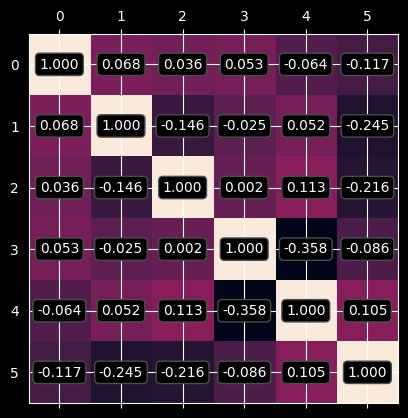

In [15]:
# tutaj dodaj swój kod
import matplotlib.pyplot as plt
sub = analysis_df.copy()[['dep_delay', 'temp', 'wind_speed', 'precip', 'visib', 'pressure']].dropna()
q3_corr = sub.corr()
grp = sub.groupby(pd.qcut(sub['pressure'], 4))
q3_pressure_groups = pd.DataFrame({
    'flights_n': grp.size(),
    'dep_delay_mean': grp.dep_delay.agg('mean'),
    'dep_delay_median': grp.dep_delay.agg('median'),
})
display(q3_corr)
display(q3_pressure_groups)

fig, ax = plt.subplots()
ax.matshow(q3_corr)
for (i, j), z in np.ndenumerate(q3_corr):
    ax.text(j, i, f'{z:0.3f}', ha='center', va='center', bbox={'boxstyle':
                                                               'round', 'facecolor': 'black', 'edgecolor': '0.3'})
plt.show()

## <span style="color:#0f766e; font-weight:700;">Zadanie 13</span>

Q4: Sprawdź punktualność w czasie.

Pracuj na `analysis_df`.

Przygotuj trzy wyniki:
1. `q4_month` przez grupowanie po `month_num`
2. `q4_weekday` przez grupowanie po `weekday`
3. `q4_hour_pivot` jako tabelę `weekday x dep_hour`

W `q4_month` i `q4_weekday` policz:
- `flights_n`
- `on_time_rate`
- `dep_delay_median`

Przyjmij:
- `on_time_rate = 1 - mean(is_delayed_dep)`

W `q4_hour_pivot` użyj:
- `index='weekday'`
- `columns='dep_hour'`
- `values='is_delayed_dep'`
- `aggfunc='mean'`

Wymagane funkcje/parametry:
- `groupby().agg()` - podsumowania miesięczne i tygodniowe.
- `pivot_table()` - tabela do dalszej heatmapy.
- `sort_index()` albo `sort_values()` - uporządkowanie wyników.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html


In [16]:
# tutaj dodaj swój kod
# 1. `q4_month` przez grupowanie po `month_num`
# 2. `q4_weekday` przez grupowanie po `weekday`
# 3. `q4_hour_pivot` jako tabelę `weekday x dep_hour`
#
# W `q4_month` i `q4_weekday` policz:
# - `flights_n`
# - `on_time_rate`
# - `dep_delay_median`
#
# Przyjmij:
# - `on_time_rate = 1 - mean(is_delayed_dep)`
#
# W `q4_hour_pivot` użyj:
# - `index='weekday'`
# - `columns='dep_hour'`
# - `values='is_delayed_dep'`
# - `aggfunc='mean'`
#
# Wymagane funkcje/parametry:
# - `groupby().agg()` - podsumowania miesięczne i tygodniowe.
# - `pivot_table()` - tabela do dalszej heatmapy.
# - `sort_index()` albo `sort_values()` - uporządkowanie wyników.
copied = analysis_df.copy()
q4_month_grp = copied.groupby('month_num')
q4_month = pd.DataFrame({
    'flights_n': q4_month_grp.size(),
    'on_time_rate': q4_month_grp.is_delayed_dep.agg('mean').map(lambda x: 1-x),
    'dep_delay_median': q4_month_grp.dep_delay.agg('median'),
})
q4_weekday_grp = copied.groupby('weekday')
q4_weekday = pd.DataFrame({
    'flights_n': q4_weekday_grp.size(),
    'on_time_rate': q4_weekday_grp.is_delayed_dep.agg('mean').map(lambda x: 1-x),
    'dep_delay_median': q4_weekday_grp.dep_delay.agg('median'),
})
dictionary = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5,
    'Sunday': 6,
}
dictionary_rev = {value: key for key, value in dictionary.items()}
q4_weekday.index = q4_weekday.index.map(lambda x: dictionary[x])
q4_weekday = q4_weekday.sort_index()
q4_weekday.index = q4_weekday.index.map(lambda x: dictionary_rev[x])

q4_hour_pivot = copied.pivot_table(index='weekday', columns='dep_hour', values='is_delayed_dep', aggfunc='mean')
q4_hour_pivot.index = q4_hour_pivot.index.map(lambda x: dictionary[x])
q4_hour_pivot = q4_hour_pivot.sort_index()
q4_hour_pivot.index = q4_hour_pivot.index.map(lambda x: dictionary_rev[x])

display(q4_month)
display(q4_weekday)
display(q4_hour_pivot)

,flights_n,on_time_rate,dep_delay_median
month_num,,,
1,25592,0.816153,-2.0
2,22939,0.795588,-2.0
3,27131,0.777966,-1.0
4,26852,0.773872,-2.0
5,27495,0.771195,-1.0
6,26311,0.714796,0.0
7,27418,0.705741,0.0
8,28023,0.780966,-1.0
9,26409,0.861373,-3.0


,flights_n,on_time_rate,dep_delay_median
weekday,,,
Monday,48168,0.766546,-1.0
Tuesday,48151,0.794418,-2.0
Wednesday,47502,0.800703,-2.0
Thursday,47151,0.759793,-1.0
Friday,47252,0.755947,-1.0
Saturday,38802,0.808695,-2.0
Sunday,41808,0.819293,-2.0


dep_hour,0,1,2,3,4,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,
Monday,0.362985,0.379310,0.402228,0.472868,0.500000,0.050000,0.074845,0.086881,0.104962,0.130905,0.160610,0.159120,0.185039,0.223312,0.254650,0.303347,0.305759,0.324154,0.327103,0.350955
Tuesday,0.353952,0.362405,0.286420,0.388060,NaN,0.044872,0.067437,0.067009,0.102211,0.112419,0.125196,0.158879,0.173896,0.201706,0.223525,0.244289,0.271863,0.280011,0.285582,0.298318
Wednesday,0.306383,0.310934,0.306864,0.306569,0.000000,0.065359,0.061481,0.068895,0.091333,0.114223,0.122116,0.129826,0.169639,0.206013,0.214822,0.245318,0.260953,0.282721,0.295000,0.317369
Thursday,0.325499,0.349342,0.303401,0.298387,0.000000,0.070968,0.065975,0.074670,0.104465,0.121913,0.145047,0.159352,0.203213,0.265101,0.285714,0.319758,0.338521,0.364140,0.355408,0.391474
Friday,0.423032,0.431362,0.365183,0.315385,1.000000,0.045161,0.072123,0.093166,0.118916,0.135049,0.151527,0.184065,0.197268,0.240576,0.256655,0.297036,0.307145,0.341548,0.334717,0.367595
Saturday,0.399088,0.404029,0.346667,0.245902,0.333333,0.062500,0.078490,0.090521,0.104411,0.115958,0.135544,0.149137,0.136226,0.164830,0.174021,0.202698,0.212913,0.212032,0.213079,0.244282
Sunday,0.242926,0.191511,0.200405,0.235294,NaN,0.047619,0.062764,0.064863,0.070616,0.097236,0.110018,0.105312,0.129112,0.144131,0.172932,0.222812,0.246611,0.279063,0.296203,0.331216


## <span style="color:#0f766e; font-weight:700;">Zadanie 14</span>

Przygotuj dwa przekrojowe podsumowania: `pivot_table()` i `crosstab()`.

Pracuj na `analysis_df`.

Zrób dokładnie:
1. `q14_pivot` ze średnim `dep_delay` w układzie:
   - wiersze: `origin`
   - kolumny: `carrier`
   - wartości: `dep_delay`
2. `q14_crosstab` z udziałem klas `dep_delay_class`:
   - wiersze: `origin`
   - kolumny: `dep_delay_class`
   - normalizacja: `normalize='index'`

Na końcu pokaż obie tabele.

Wymagane funkcje/parametry:
- `pivot_table()` - tabela przestawna z agregacją.
- `pd.crosstab(..., normalize='index')` - udział klas w wierszach.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html
- https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html


In [20]:
# tutaj dodaj swój kod
# Zrób dokładnie:
# 1. `q14_pivot` ze średnim `dep_delay` w układzie:
#    - wiersze: `origin`
#    - kolumny: `carrier`
#    - wartości: `dep_delay`
# 2. `q14_crosstab` z udziałem klas `dep_delay_class`:
#    - wiersze: `origin`
#    - kolumny: `dep_delay_class`
#    - normalizacja: `normalize='index'`
#
# Na końcu pokaż obie tabele.
#
# Wymagane funkcje/parametry:
# - `pivot_table()` - tabela przestawna z agregacją.
# - `pd.crosstab(..., normalize='index')` - udział klas w wierszach.
copied = analysis_df.copy()
q4_pivot = copied.pivot_table(index='origin', columns='carrier', values='dep_delay', aggfunc='mean')

q14_crosstab = pd.crosstab(index=copied['origin'], columns=copied['dep_delay_class'], normalize='index')

display(q4_pivot)
display(q14_crosstab)

carrier,9E,AA,AS,B6,DL,EV,F9,FL,MQ,OO,UA,US,VX,WN,YV
origin,,,,,,,,,,,,,,,
EWR,5.656329,8.876043,5.830748,13.183207,10.497315,19.814307,NaN,NaN,15.516746,20.833333,12.223084,3.503700,11.529336,17.518261,NaN
JFK,18.438506,10.168114,NaN,12.609310,7.918453,16.962150,NaN,NaN,12.463554,NaN,7.660858,5.741141,12.176884,NaN,NaN
LGA,8.709623,6.323983,NaN,14.425669,8.672876,18.573759,18.371134,16.876028,8.412956,10.434783,11.248619,3.187096,NaN,17.070222,18.220994


dep_delay_class,early,on_time,delay_16_60
origin,,,
EWR,0.958404,0.040823,0.000773
JFK,0.964985,0.034333,0.000682
LGA,0.967119,0.031931,0.000950


## <span style="color:#0f766e; font-weight:700;">Zadanie 15</span>

Q5: Zbuduj końcowy audyt i mini-raport projektu.

Pracuj na wynikach z poprzednich zadań.

Twoja odpowiedź ma mieć 3 części:

1. Tabela audytu
   Zbuduj tabelę z krokami:
   - `flights raw`
   - `flights after_dropna`
   - `flights after_range_validation`
   - `weather raw`
   - `weather after_dedupe`
   - `analysis final_after_merges`

   Dla każdego kroku pokaż:
   - `dataset`
   - `step`
   - `rows`
   - `removed_vs_prev`

2. Trzy wykresy
   Zrób dokładnie trzy wykresy:
   - ranking przewoźników z Q1,
   - ranking kierunków z Q2,
   - `on_time_rate` wg miesiąca z Q4.

3. Krótkie wnioski tekstowe
   Napisz po 1 krótkiej odpowiedzi do:
   - Q1
   - Q2
   - Q3
   - Q4
   - Q5

Wymagane funkcje/parametry:
- `pd.DataFrame()` - tabela audytu.
- `matplotlib` i `seaborn` - trzy wykresy.
- krótkie wnioski tekstowe oparte na wcześniej policzonych wynikach.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://matplotlib.org/stable/api/pyplot_summary.html
- https://seaborn.pydata.org/


,dataset,step,rows,removed_vs_prev
0,flights,raw,336776,0
1,flights,after_dropna,327346,9430
2,flights,after_range_validation,326369,977
3,weather,raw,26115,0
4,weather,after_dedupe,26112,3
5,analysis,final_after_merges,318834,17942


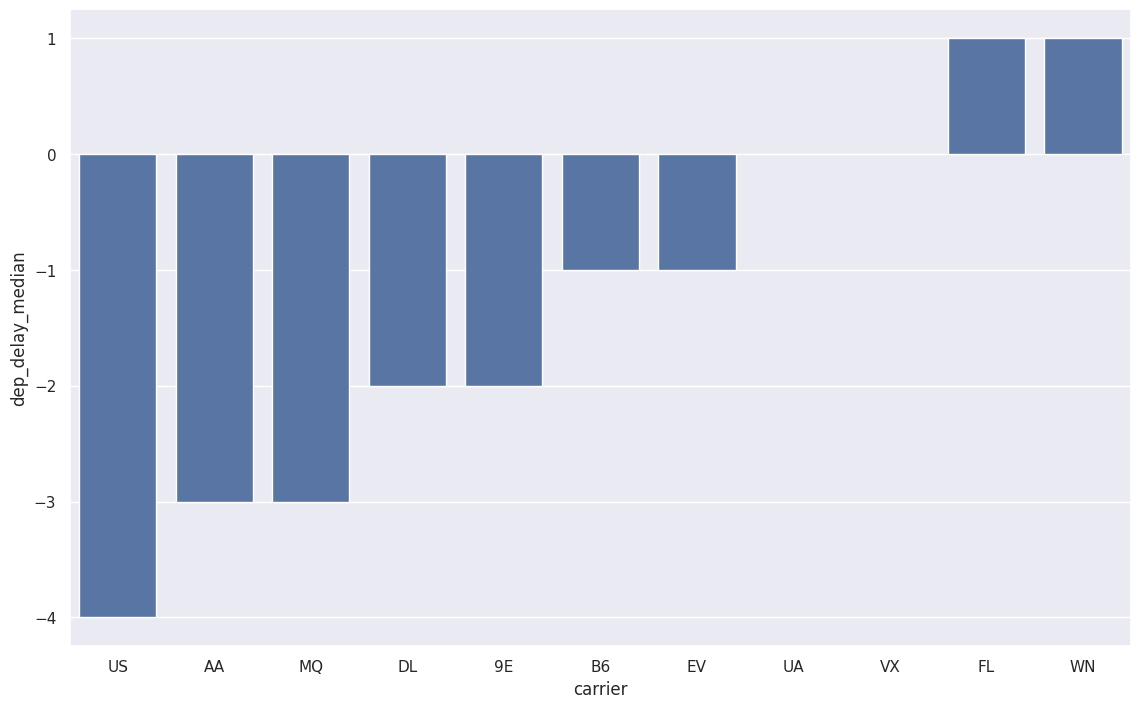

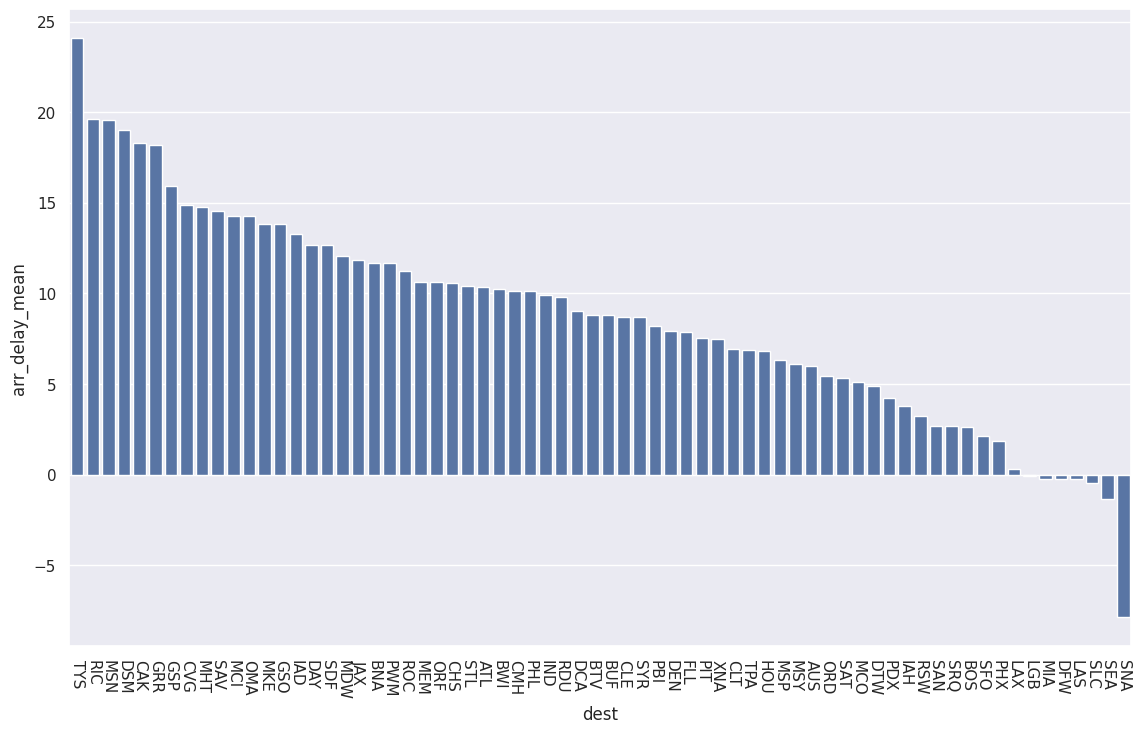

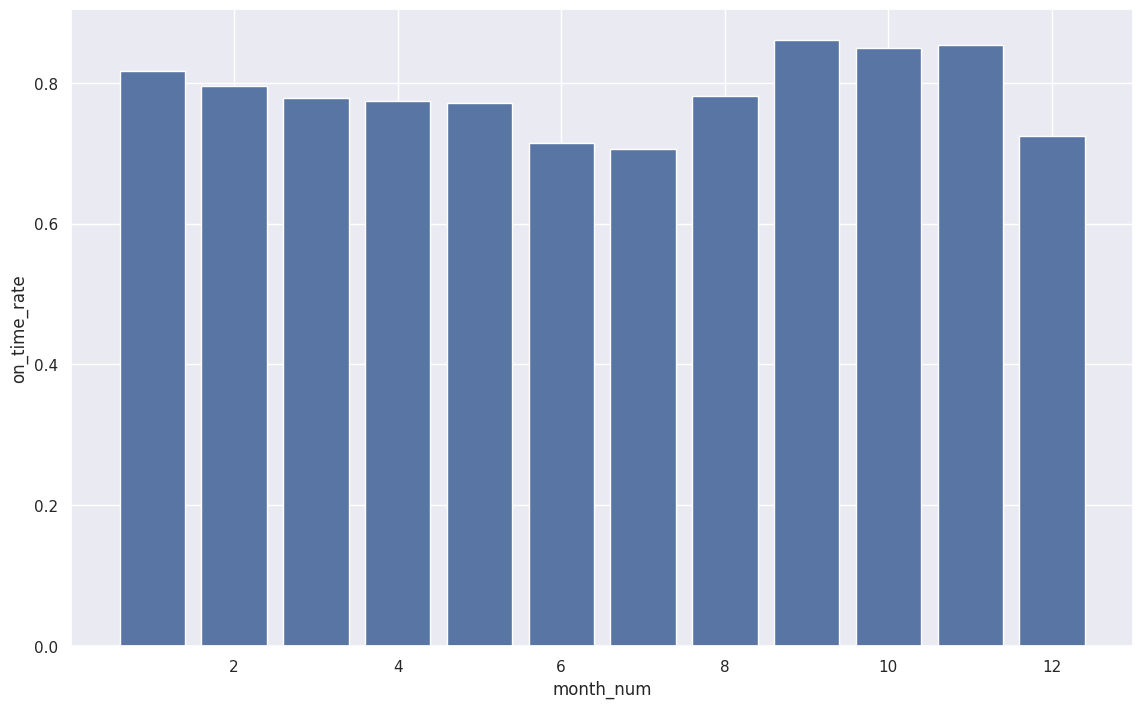

In [46]:
# tutaj dodaj swój kod
# 1. Tabela audytu
#    Zbuduj tabelę z krokami:
#    - `flights raw`
#    - `flights after_dropna`
#    - `flights after_range_validation`
#    - `weather raw`
#    - `weather after_dedupe`
#    - `analysis final_after_merges`
#
#    Dla każdego kroku pokaż:
#    - `dataset`
#    - `step`
#    - `rows`
#    - `removed_vs_prev`
#
# 2. Trzy wykresy
#    Zrób dokładnie trzy wykresy:
#    - ranking przewoźników z Q1, dep_delay_median
#    - ranking kierunków z Q2, arr_delay_mean
#    - `on_time_rate` wg miesiąca z Q4.
#
# 3. Krótkie wnioski tekstowe
#    Napisz po 1 krótkiej odpowiedzi do:
#    - Q1
#    - Q2
#    - Q3
#    - Q4
#    - Q5
#
# Wymagane funkcje/parametry:
# - `pd.DataFrame()` - tabela audytu.
# - `matplotlib` i `seaborn` - trzy wykresy.
# - krótkie wnioski tekstowe oparte na wcześniej policzonych wynikach.

import seaborn as sns

audit = pd.DataFrame({
    'dataset': ['flights', 'flights', 'flights', 'weather', 'weather', 'analysis'],
    'step': ['raw', 'after_dropna', 'after_range_validation', 'raw', 'after_dedupe', 'final_after_merges'],
    'rows': [len(flights_raw), len(flights_no_missing), len(flights_clean), len(weather), len(weather_clean), len(analysis_df)],
    'removed_vs_prev': [0, len(flights_raw)-len(flights_no_missing), len(flights_no_missing)-len(flights_clean), 0, len(weather)-len(weather_clean),len(flights_raw)-len(analysis_df)],
})
display(audit)
sns.set_theme(rc={'figure.figsize':(13.7,8.27)})
sns.barplot(carrier_rank, x='carrier', y='dep_delay_median', native_scale=True)
plt.show()
sns.barplot(dest_rank, x='dest', y='arr_delay_mean', native_scale=True)
plt.xticks(rotation=-90)
plt.show()
sns.barplot(q4_month, x='month_num', y='on_time_rate', native_scale=True)
plt.show()

# <span style="color:#0f766e; font-weight:700;">5. Zadania dodatkowe (16-24)</span>


## <span style="color:#0f766e; font-weight:700;">Zadanie 16 - dodatkowe</span>

Zbuduj heatmapę `weekday x dep_hour` dla `on_time_rate`.

Pracuj na `q4_hour_pivot` z zadania 13.

Pokaż heatmapę, w której:
- wiersze to `weekday`,
- kolumny to `dep_hour`,
- kolor pokazuje `on_time_rate`.

Jeśli Twoja tabela zawiera średnią z `is_delayed_dep`, pamiętaj, że:
- `on_time_rate = 1 - mean(is_delayed_dep)`.

Wymagane funkcje/parametry:
- `pivot_table()` - tabela wejściowa do heatmapy.
- `sns.heatmap()` - wizualizacja punktualności.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://seaborn.pydata.org/generated/seaborn.heatmap.html


dep_hour,0,1,2,3,4,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,
Monday,0.362985,0.379310,0.402228,0.472868,0.500000,0.050000,0.074845,0.086881,0.104962,0.130905,0.160610,0.159120,0.185039,0.223312,0.254650,0.303347,0.305759,0.324154,0.327103,0.350955
Tuesday,0.353952,0.362405,0.286420,0.388060,NaN,0.044872,0.067437,0.067009,0.102211,0.112419,0.125196,0.158879,0.173896,0.201706,0.223525,0.244289,0.271863,0.280011,0.285582,0.298318
Wednesday,0.306383,0.310934,0.306864,0.306569,0.000000,0.065359,0.061481,0.068895,0.091333,0.114223,0.122116,0.129826,0.169639,0.206013,0.214822,0.245318,0.260953,0.282721,0.295000,0.317369
Thursday,0.325499,0.349342,0.303401,0.298387,0.000000,0.070968,0.065975,0.074670,0.104465,0.121913,0.145047,0.159352,0.203213,0.265101,0.285714,0.319758,0.338521,0.364140,0.355408,0.391474
Friday,0.423032,0.431362,0.365183,0.315385,1.000000,0.045161,0.072123,0.093166,0.118916,0.135049,0.151527,0.184065,0.197268,0.240576,0.256655,0.297036,0.307145,0.341548,0.334717,0.367595
Saturday,0.399088,0.404029,0.346667,0.245902,0.333333,0.062500,0.078490,0.090521,0.104411,0.115958,0.135544,0.149137,0.136226,0.164830,0.174021,0.202698,0.212913,0.212032,0.213079,0.244282
Sunday,0.242926,0.191511,0.200405,0.235294,NaN,0.047619,0.062764,0.064863,0.070616,0.097236,0.110018,0.105312,0.129112,0.144131,0.172932,0.222812,0.246611,0.279063,0.296203,0.331216


<Axes: xlabel='dep_hour', ylabel='weekday'>

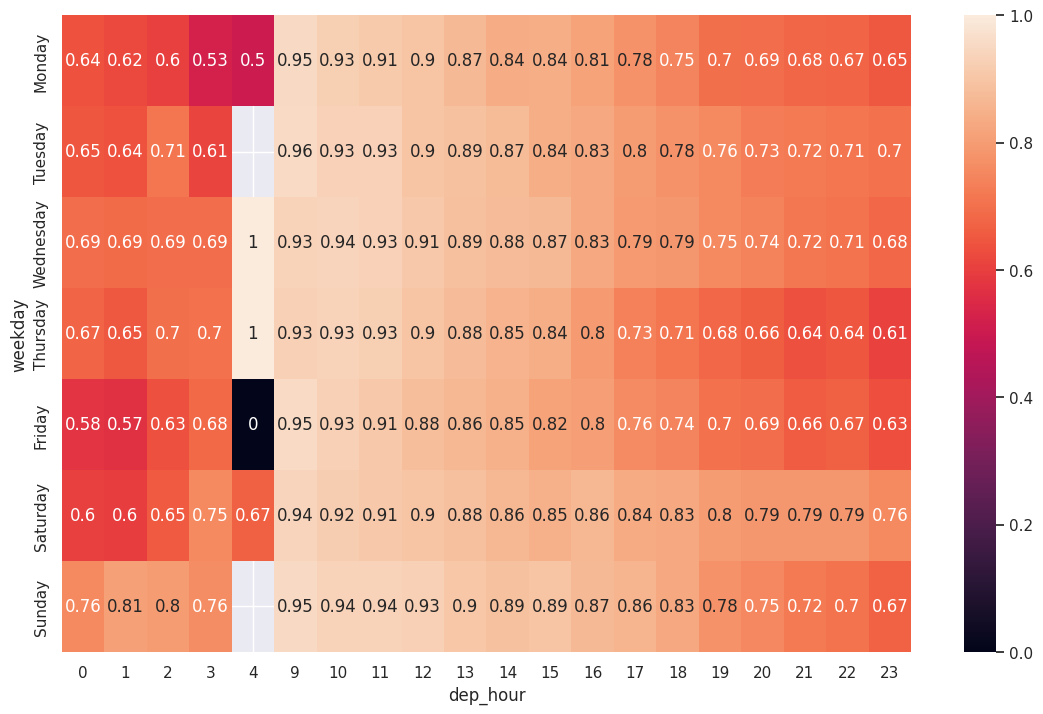

In [49]:
# tutaj dodaj swój kod
# Zbuduj heatmapę `weekday x dep_hour` dla `on_time_rate`.
#
# Pracuj na `q4_hour_pivot` z zadania 13.
#
# Pokaż heatmapę, w której:
# - wiersze to `weekday`,
# - kolumny to `dep_hour`,
# - kolor pokazuje `on_time_rate`.
#
# Jeśli Twoja tabela zawiera średnią z `is_delayed_dep`, pamiętaj, że:
# - `on_time_rate = 1 - mean(is_delayed_dep)`.
#
# Wymagane funkcje/parametry:
# - `pivot_table()` - tabela wejściowa do heatmapy.
# - `sns.heatmap()` - wizualizacja punktualności.
display(q4_hour_pivot)
q4_hour_pivot_copy = q4_hour_pivot.copy().map(lambda x: 1-x)
sns.heatmap(q4_hour_pivot_copy, annot=True)

## <span style="color:#0f766e; font-weight:700;">Zadanie 17 - dodatkowe</span>

Przeanalizuj anulowane loty.

Pracuj na surowej tabeli `flights`.

Przyjmij definicję:
- lot anulowany = rekord z brakującym `dep_time`

Przygotuj dwa wyniki:
1. `cancel_by_month` z kolumnami:
   - `flights_n`
   - `cancel_rate`
2. `cancel_by_carrier` z kolumnami:
   - `flights_n`
   - `cancel_rate`

Dla przewoźników pokaż TOP 10 po najwyższym `cancel_rate`.

Wymagane funkcje/parametry:
- `isna()` - identyfikacja anulowanych lotów przez brak `dep_time`.
- `groupby().agg()` - agregacja po miesiącu i przewoźniku.
- `sort_values()` - ranking przewoźników.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.Series.isna.html


In [57]:
# tutaj dodaj swój kod
# Przeanalizuj anulowane loty.
#
# Pracuj na surowej tabeli `flights`.
#
# Przyjmij definicję:
# - lot anulowany = rekord z brakującym `dep_time`
#
# Przygotuj dwa wyniki:
# 1. `cancel_by_month` z kolumnami:
#    - `flights_n`
#    - `cancel_rate`
# 2. `cancel_by_carrier` z kolumnami:
#    - `flights_n`
#    - `cancel_rate`
#
# Dla przewoźników pokaż TOP 10 po najwyższym `cancel_rate`.
#
# Wymagane funkcje/parametry:
# - `isna()` - identyfikacja anulowanych lotów przez brak `dep_time`.
# - `groupby().agg()` - agregacja po miesiącu i przewoźniku.
# - `sort_values()` - ranking przewoźników.
grp = flights.groupby(['month'])
cancel_by_month = pd.DataFrame({
    'flights_n': grp.size(),
    'cancel_rate': grp.dep_time.agg(lambda x: sum(x.isna())/len(x)),
})
grp = flights.groupby(['carrier'])
cancel_by_carrier = pd.DataFrame({
    'flights_n': grp.size(),
    'cancel_rate': grp.dep_time.agg(lambda x: sum(x.isna())/len(x)),
})
display(cancel_by_carrier.sort_values('cancel_rate', ascending=False))

,flights_n,cancel_rate
carrier,,
OO,32,0.093750
YV,601,0.093178
9E,18460,0.056555
EV,54173,0.052000
MQ,26397,0.046748
US,20536,0.032285
FL,3260,0.022393
AA,32729,0.019432
WN,12275,0.015642


## <span style="color:#0f766e; font-weight:700;">Zadanie 18 - dodatkowe</span>

Dołącz `planes` i oceń wpływ wieku samolotu na `arr_delay`.

Pracuj na `analysis_df`.

Wykonaj kolejno:
1. z `planes` wybierz kolumny:
   - `tailnum`
   - `year`
   - `manufacturer`
   - `model`
   - `seats`
2. zmień nazwę `year` na `plane_year`,
3. skonwertuj `plane_year` do typu liczbowego,
4. połącz dane z `analysis_df` po `tailnum`,
5. policz `plane_age = year - plane_year`,
6. zbuduj `plane_age_bin` przez `pd.cut()` z przedziałami:
   - `[0, 5, 10, 20, 40, 80]`
7. policz w tych grupach:
   - `flights_n`
   - `arr_delay_mean`

Wymagane funkcje/parametry:
- `merge()` - łączenie z tabelą planes.
- `pd.to_numeric()` - konwersja roku produkcji samolotu.
- `pd.cut()` - grupowanie wieku samolotu.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html
- https://pandas.pydata.org/docs/reference/api/pandas.cut.html


In [ ]:
# tutaj dodaj swój kod
# Dołącz `planes` i oceń wpływ wieku samolotu na `arr_delay`.
#
# Pracuj na `analysis_df`.
#
# Wykonaj kolejno:
# 1. z `planes` wybierz kolumny:
#    - `tailnum`
#    - `year`
#    - `manufacturer`
#    - `model`
#    - `seats`
# 2. zmień nazwę `year` na `plane_year`,
# 3. skonwertuj `plane_year` do typu liczbowego,
# 4. połącz dane z `analysis_df` po `tailnum`,
# 5. policz `plane_age = year - plane_year`,
# 6. zbuduj `plane_age_bin` przez `pd.cut()` z przedziałami:
#    - `[0, 5, 10, 20, 40, 80]`
# 7. policz w tych grupach:
#    - `flights_n`
#    - `arr_delay_mean`
#
# Wymagane funkcje/parametry:
# - `merge()` - łączenie z tabelą planes.
# - `pd.to_numeric()` - konwersja roku produkcji samolotu.
# - `pd.cut()` - grupowanie wieku samolotu.


## <span style="color:#0f766e; font-weight:700;">Zadanie 19 - dodatkowe</span>

Znajdź najbardziej niestabilne trasy.

Pracuj na `analysis_df`.

Wykonaj kolejno:
1. utwórz `route = origin + '-' + dest`,
2. pogrupuj po `route`,
3. policz:
   - `flights_n`
   - `arr_delay_std`
   - `arr_delay_mean`
4. zostaw tylko trasy z minimum `200` lotów,
5. posortuj malejąco po `arr_delay_std`,
6. pokaż TOP 15.

Wymagane funkcje/parametry:
- `assign()` - utworzenie zmiennej `route`.
- `groupby().agg()` - liczebność i zmienność opóźnień.
- `query()` i `sort_values()` - ranking tras.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.std.html


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 20 - dodatkowe</span>

Porównaj średnią, medianę i średnią obciętą `dep_delay` dla przewoźników.

Pracuj na `analysis_df`.

Wykonaj kolejno:
1. napisz własną funkcję `trimmed_mean()`,
2. dla każdego `carrier` policz:
   - `flights_n`
   - `dep_delay_mean`
   - `dep_delay_median`
   - `dep_delay_trimmed`
3. zostaw tylko przewoźników z minimum `1000` lotów,
4. posortuj wynik po `dep_delay_median`.

Jeśli chcesz, możesz przyjąć obcięcie 10% obserwacji z obu stron rozkładu.

Wymagane funkcje/parametry:
- własna funkcja `trimmed_mean()` - średnia obcięta.
- `groupby().agg()` - zestaw kilku miar naraz.
- `query()` i `sort_values()` - końcowa tabela rankingowa.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://docs.python.org/3/tutorial/controlflow.html#defining-functions


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 21 - dodatkowe</span>

Policz bootstrapowy 95% CI dla mediany `dep_delay` dla dwóch przewoźników.

Pracuj na `analysis_df`.

Wybierz dwóch największych przewoźników według liczby lotów. Następnie dla każdego z nich:
1. pobierz wektor `dep_delay`,
2. wykonaj bootstrap z losowaniem ze zwracaniem,
3. policz 1000 bootstrapowych median,
4. wyznacz:
   - medianę z danych,
   - `ci95_low`,
   - `ci95_high`

Końcowy wynik pokaż w tabeli z kolumnami:
- `carrier`
- `median_dep_delay`
- `ci95_low`
- `ci95_high`

Wymagane funkcje/parametry:
- `np.random.default_rng()` - losowanie bootstrapowe.
- `np.percentile()` - przedział ufności z rozkładu bootstrapowego.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://numpy.org/doc/stable/reference/generated/numpy.percentile.html


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 22 - dodatkowe</span>

Zbuduj prosty baseline `arr_delay ~ dep_delay + distance`.

Pracuj na `analysis_df`.

Wykonaj kolejno:
1. zbuduj podzbiór bez braków dla:
   - `arr_delay`
   - `dep_delay`
   - `distance`
2. policz macierz korelacji,
3. dopasuj prostą `arr_delay ~ dep_delay` przez `np.polyfit()`,
4. wypisz:
   - macierz korelacji,
   - `slope`,
   - `intercept`

Nie budujesz tu modelu ML, tylko bardzo prosty baseline opisowy.

Wymagane funkcje/parametry:
- `corr()` - korelacje między zmiennymi.
- `np.polyfit()` - prosta linia trendu.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 23 - dodatkowe</span>

Wyeksportuj oczyszczoną tabelę i kluczowe wyniki.

Pracuj na:
- `analysis_df`
- `q1_carriers`
- `q2_destinations`

Wykonaj kolejno:
1. utwórz folder `dane_lekcja4_wyniki`,
2. zapisz do CSV:
   - `analysis_df`
   - `q1_carriers`
   - `q2_destinations`
3. przygotuj krótki słownik z metrykami:
   - `rows_final`
   - najlepszy przewoźnik
   - najgorszy kierunek
4. zapisz ten słownik do JSON.

Wymagane funkcje/parametry:
- `to_csv(index=False)` - eksport tabel do CSV.
- `json.dump(..., indent=2)` - eksport krótkiego raportu do JSON.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html
- https://docs.python.org/3/library/json.html


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 24 - dodatkowe</span>

Napisz funkcję `run_lesson4_pipeline()` zwracającą słownik wyników Q1-Q5.

Twoja funkcja ma samodzielnie wykonać główny pipeline:
1. import danych,
2. przygotowanie `project_flights`,
3. `dropna()` i walidację zakresów,
4. budowę cech czasu i opóźnień,
5. przygotowanie `weather_clean`,
6. merge z `airlines`, `airports` i `weather`,
7. policzenie podstawowych wyników:
   - ranking przewoźników,
   - ranking kierunków,
   - korelacje pogodowe,
   - podsumowanie miesięczne,
   - audyt liczby usuniętych rekordów

Funkcja powinna zwrócić `dict` z kluczami:
- `analysis_df`
- `q1_carriers`
- `q2_destinations`
- `q3_corr`
- `q4_month`
- `q5_audit`

Wymagane funkcje/parametry:
- `def` - utworzenie funkcji.
- `dict` - zwrot wyników w uporządkowanej postaci.
- `dropna()`, `between()`, `merge()`, `groupby()` - główne kroki pipeline'u.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://docs.python.org/3/tutorial/controlflow.html#defining-functions


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Najczęstsze błędy</span>


- łączenie `weather` bez wcześniejszego usunięcia duplikatów po kluczu,
- porównywanie przewoźników bez minimalnej liczebności lotów,
- interpretacja średnich opóźnień bez mediany i liczby obserwacji,
- brak audytu: ile rekordów odpadło na `dropna`, ile na walidacji zakresów, ile przy merge,
- traktowanie anulowanych lotów i braków tak, jakby były zwykłymi obserwacjami,
- budowanie wykresów bez wcześniejszego sprawdzenia, jakie rekordy weszły do analizy.
